# Datathon 7MLET - Grupo 13
## Plataforma de Experimentacao Adaptativa para Ofertas com Multi-Armed Bandit

**Aluna:** Giovanna Catelli

**Dataset:** [bank-marketing (henriqueyamahata)](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing)

---

## Secao 0: Setup e Dependencias

In [1]:
# Instalar dependencias que nao vem no Kaggle
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 10.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mlflow
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print('Setup concluido com sucesso!')

Setup concluido com sucesso!


---
## Secao 1: Carregamento dos Dados

In [3]:
import os

# Tentar path do Kaggle primeiro, depois path local
possible_paths = [
    '/kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-full.csv',
    '/kaggle/input/bank-marketing/bank-additional-full.csv',
    '/kaggle/input/bank-marketing/bank.csv',
    '/kaggle/input/bank-marketing/bank-full.csv',
    '../data/bank-additional-full.csv',
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path, sep=';')
        print(f'Dados carregados de: {path}')
        break

if df is None:
    raise FileNotFoundError('Dataset nao encontrado. Adicione bank-marketing como Input no Kaggle.')

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
df.head()

Dados carregados de: /kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-full.csv
Shape: (41188, 21)
Colunas: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---
## Secao 2: EDA (Analise Exploratoria de Dados)

In [4]:
# Informacoes gerais do dataset
print('=' * 60)
print('INFORMACOES DO DATASET')
print('=' * 60)
print(f'\nShape: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'\nTipos de dados:')
print(df.dtypes)
print(f'\nValores nulos:')
print(df.isnull().sum())
print(f'\nEstatisticas descritivas:')
df.describe()

INFORMACOES DO DATASET

Shape: 41188 linhas x 21 colunas

Tipos de dados:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Valores nulos:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


DISTRIBUICAO DO TARGET

Coluna target: y

Distribuicao:
y
no     36548
yes     4640
Name: count, dtype: int64

Proporcao:
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


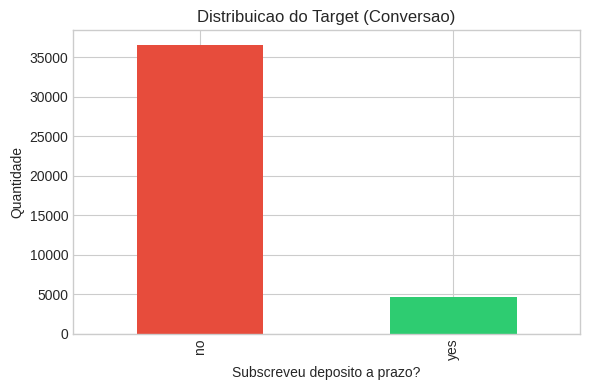

In [5]:
# Analise do target (variavel y)
print('=' * 60)
print('DISTRIBUICAO DO TARGET')
print('=' * 60)

target_col = 'y' if 'y' in df.columns else 'deposit'
print(f'\nColuna target: {target_col}')
print(f'\nDistribuicao:')
print(df[target_col].value_counts())
print(f'\nProporcao:')
print(df[target_col].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Distribuicao do Target (Conversao)')
ax.set_xlabel('Subscreveu deposito a prazo?')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

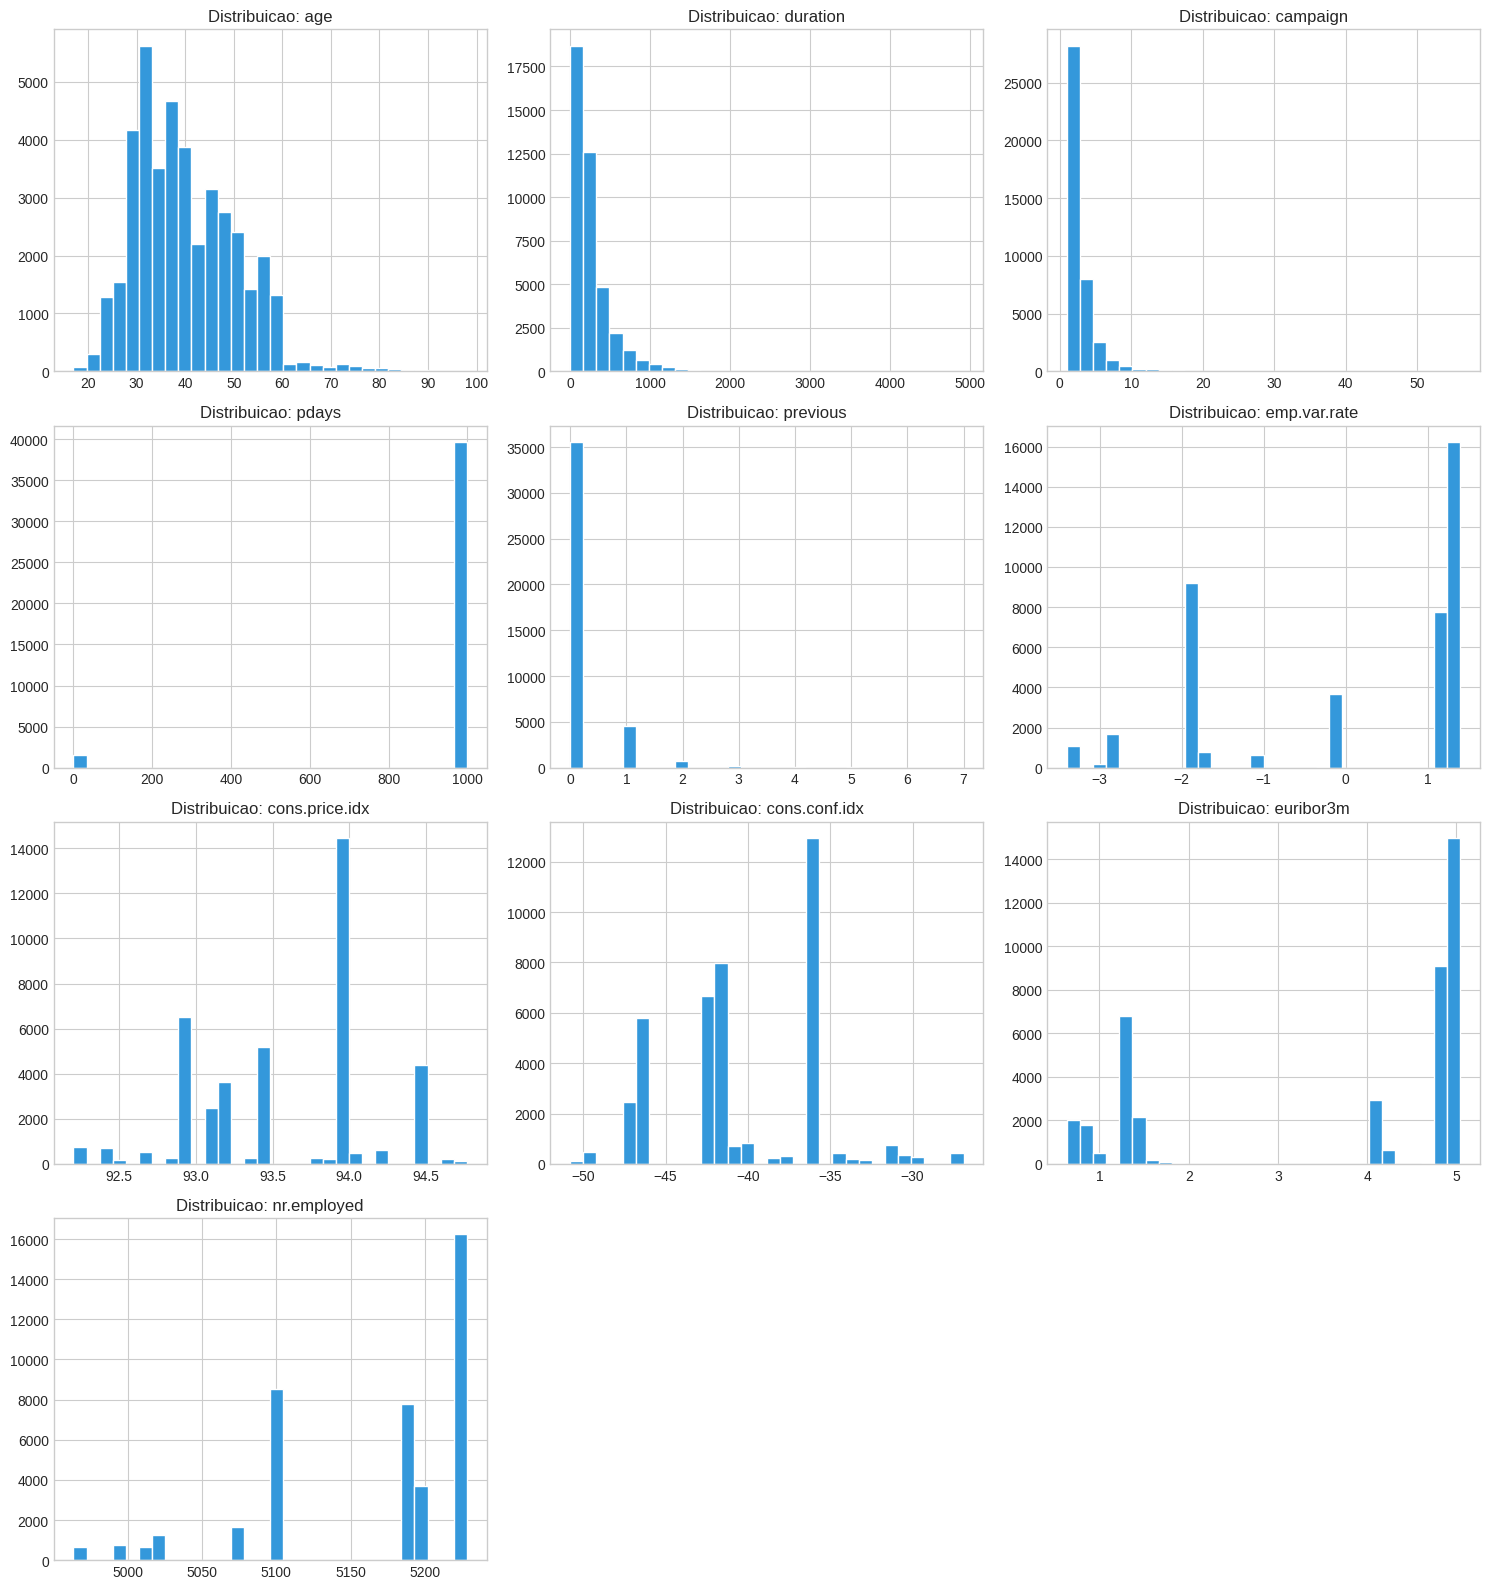

In [6]:
# Distribuicao de variaveis numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_rows = len(num_cols) // 3 + 1
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(bins=30, ax=axes[i], color='#3498db', edgecolor='white')
    axes[i].set_title(f'Distribuicao: {col}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

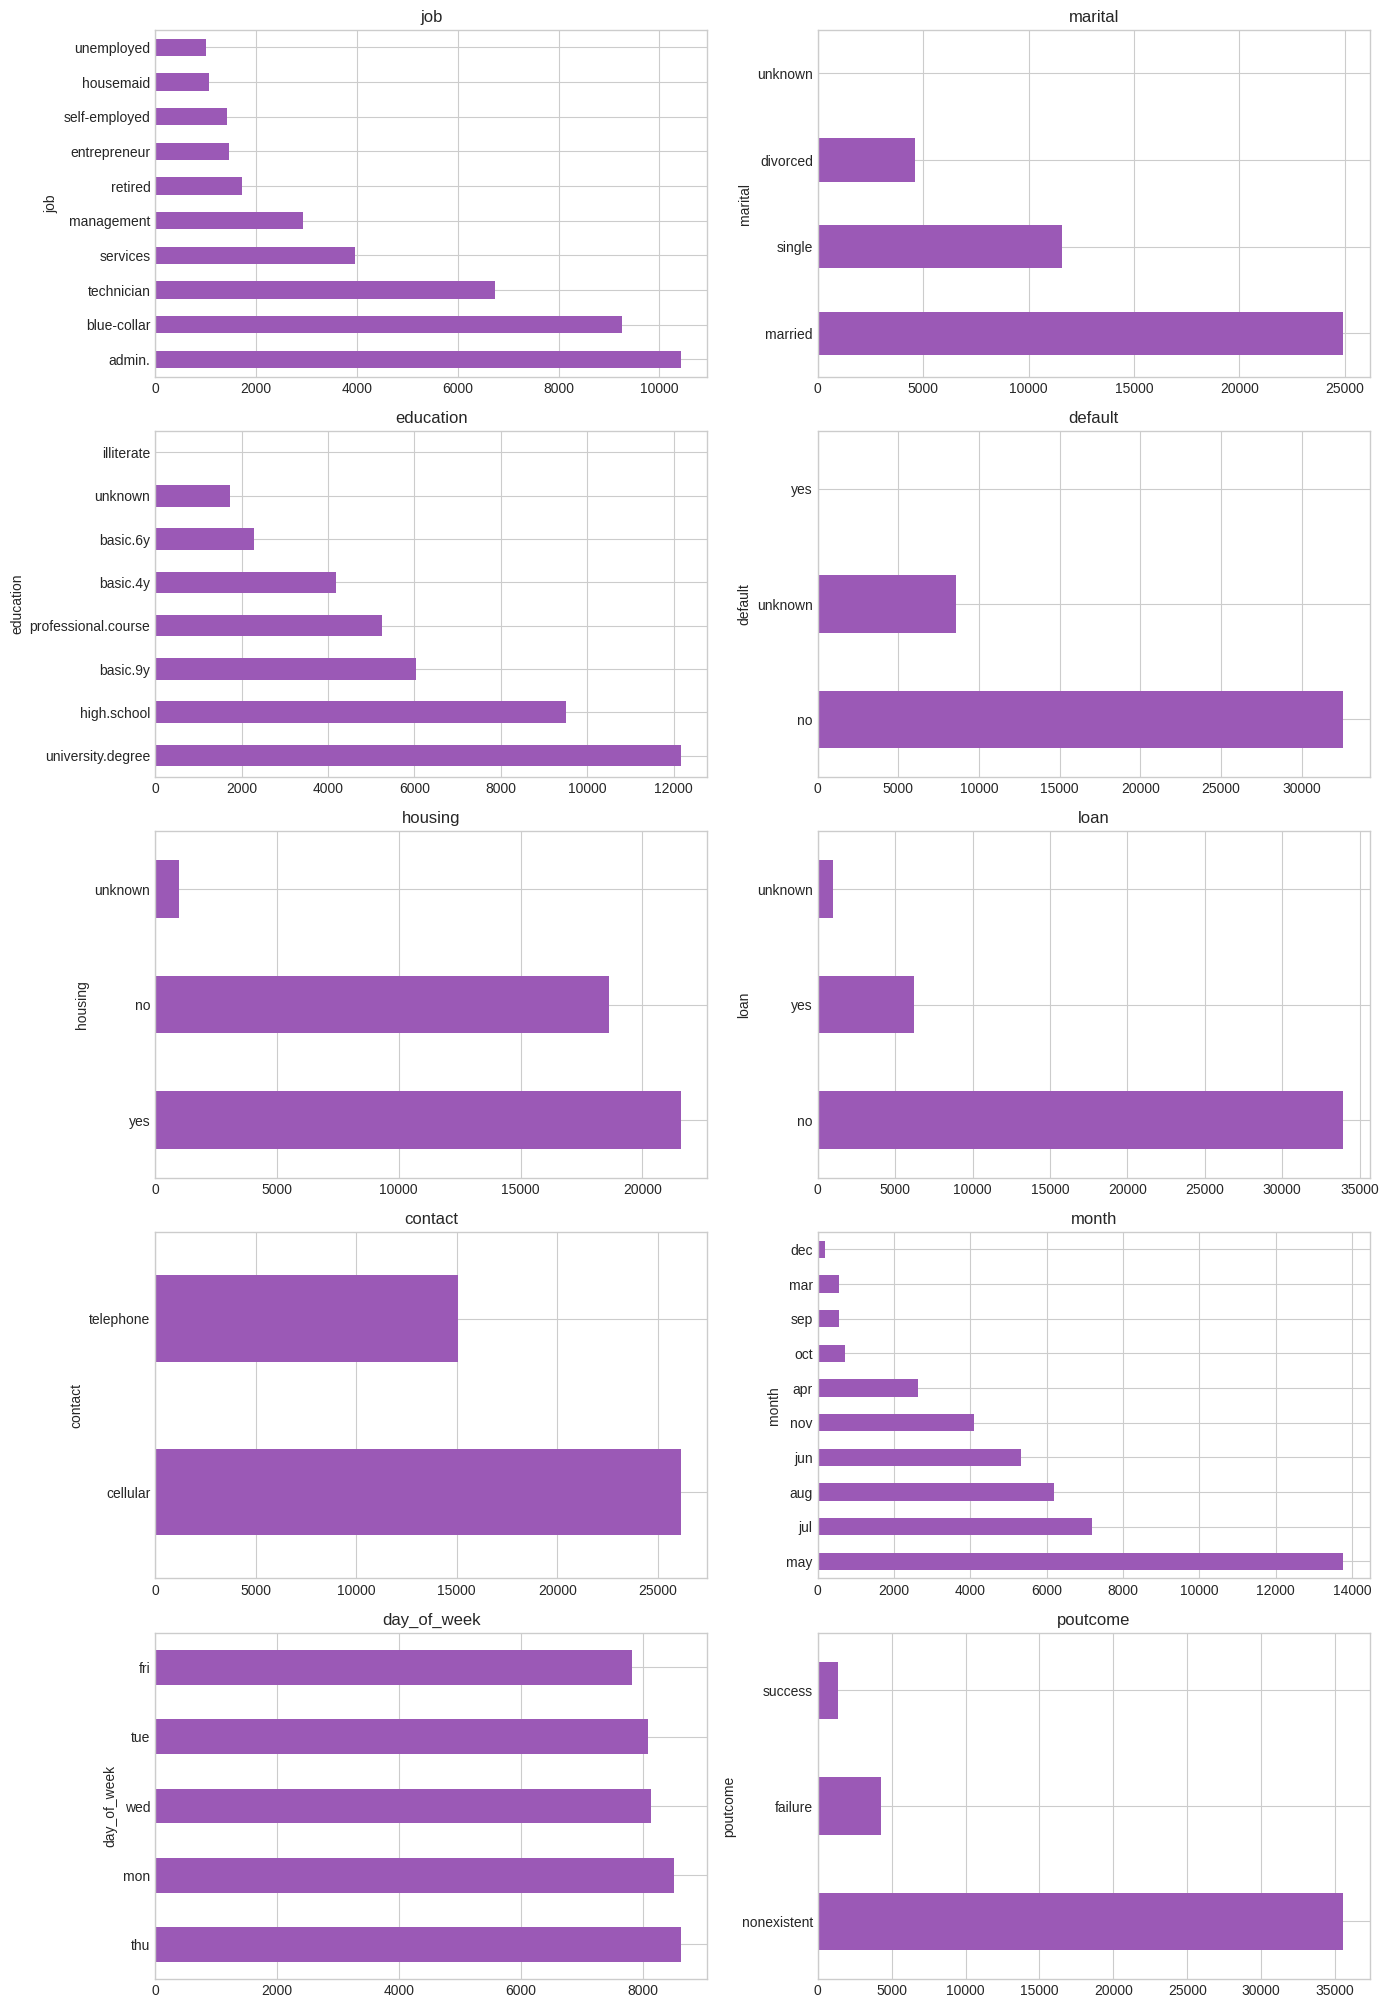

In [7]:
# Distribuicao de variaveis categoricas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

n_rows = len(cat_cols) // 2 + 1
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().head(10).plot(kind='barh', ax=axes[i], color='#9b59b6')
    axes[i].set_title(f'{col}')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

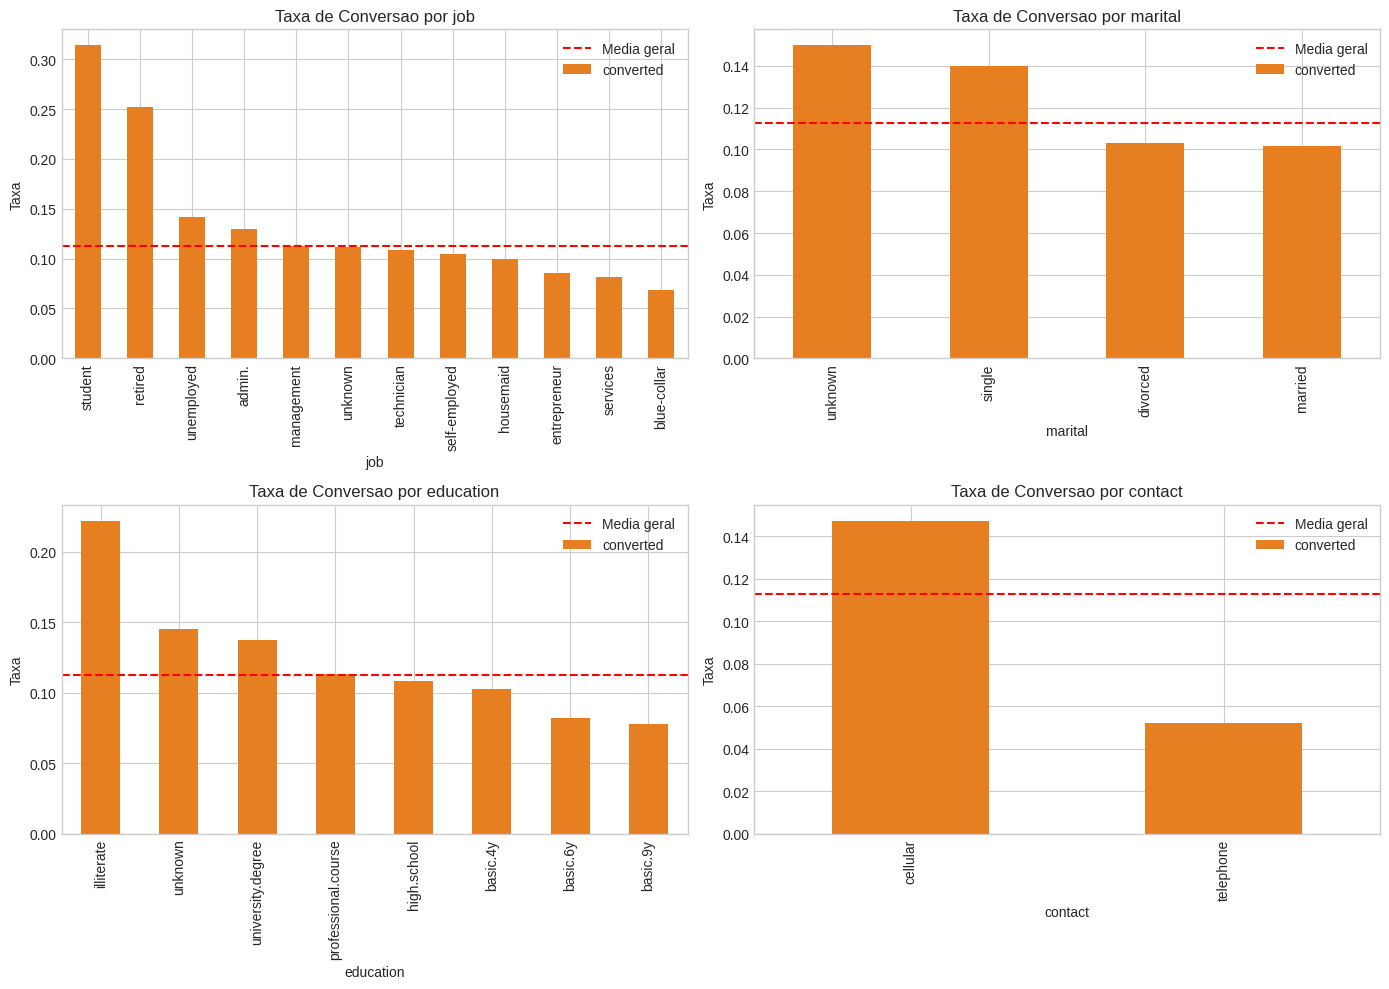

In [8]:
# Taxa de conversao por variaveis categoricas principais
df['converted'] = (df[target_col] == 'yes').astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

key_cats = ['job', 'marital', 'education', 'contact']
for ax, col in zip(axes.flatten(), key_cats):
    if col in df.columns:
        conv_rate = df.groupby(col)['converted'].mean().sort_values(ascending=False)
        conv_rate.plot(kind='bar', ax=ax, color='#e67e22')
        ax.set_title(f'Taxa de Conversao por {col}')
        ax.set_ylabel('Taxa')
        ax.axhline(y=df['converted'].mean(), color='red', linestyle='--', label='Media geral')
        ax.legend()

plt.tight_layout()
plt.show()

---
## Secao 3: Preparacao de Dados e Feature Engineering

In [9]:
# Remover coluna 'duration' (vazamento temporal)
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print('Coluna duration removida (vazamento temporal)')

print(f'Shape apos remocao: {df.shape}')

Coluna duration removida (vazamento temporal)
Shape apos remocao: (41188, 21)


In [10]:
# Tratar valores 'unknown'
print('Valores unknown por coluna:')
for col in df.columns:
    if df[col].dtype == 'object':
        unknowns = (df[col] == 'unknown').sum()
        if unknowns > 0:
            print(f'  {col}: {unknowns} ({unknowns/len(df)*100:.1f}%)')

Valores unknown por coluna:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


In [11]:
# Feature Engineering
# Criar faixa etaria
df['faixa_etaria'] = pd.cut(df['age'], bins=[0, 30, 45, 55, 100],
                            labels=['jovem', 'adulto', 'senior', 'idoso'])

# Flag de contato anterior
if 'pdays' in df.columns:
    df['teve_contato_anterior'] = (df['pdays'] != -1).astype(int) if -1 in df['pdays'].values else (df['pdays'] != 999).astype(int)

# Flag de sucesso anterior
if 'poutcome' in df.columns:
    df['sucesso_anterior'] = (df['poutcome'] == 'success').astype(int)

print('Features criadas:')
print('  - faixa_etaria')
print('  - teve_contato_anterior')
print('  - sucesso_anterior')
df[['age', 'faixa_etaria', 'teve_contato_anterior', 'sucesso_anterior']].head(10)

Features criadas:
  - faixa_etaria
  - teve_contato_anterior
  - sucesso_anterior


,age,faixa_etaria,teve_contato_anterior,sucesso_anterior
0,56,idoso,0,0
1,57,idoso,0,0
2,37,adulto,0,0
3,40,adulto,0,0
4,56,idoso,0,0
5,45,adulto,0,0
6,59,idoso,0,0
7,41,adulto,0,0
8,24,jovem,0,0
9,25,jovem,0,0


In [12]:
# Encoding de variaveis categoricas
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

cat_cols_encode = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
if target_col in cat_cols_encode:
    cat_cols_encode.remove(target_col)

for col in cat_cols_encode:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Target binario
df_encoded['target'] = (df_encoded[target_col] == 'yes').astype(int)

print(f'Dataset codificado: {df_encoded.shape}')
df_encoded.head()

Dataset codificado: (41188, 25)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,converted,faixa_etaria,teve_contato_anterior,sucesso_anterior,target
0,56,3,1,0,0,0,0,1,6,1,...,93.994,-36.4,4.857,5191.0,no,0,1,0,0,0
1,57,7,1,3,1,0,0,1,6,1,...,93.994,-36.4,4.857,5191.0,no,0,1,0,0,0
2,37,7,1,3,0,2,0,1,6,1,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,0
3,40,0,1,1,0,0,0,1,6,1,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,0
4,56,7,1,3,0,0,2,1,6,1,...,93.994,-36.4,4.857,5191.0,no,0,1,0,0,0


In [13]:
# Definicao dos bracos (ofertas) do Bandit
# Simular 4 bracos representando diferentes estrategias de oferta

BRACOS = {
    0: 'Deposito a prazo (padrao)',
    1: 'Deposito com taxa premium',
    2: 'Produto alternativo (emprestimo)',
    3: 'Controle (nao contatar)'
}

print('Bracos definidos:')
for k, v in BRACOS.items():
    print(f'  Braco {k}: {v}')

# Definir funcao de reward simulado baseada no perfil do cliente e braco
def calcular_prob_conversao(row, braco):
    """
    Calcula a PROBABILIDADE de conversao dado um cliente e um braco.
    Cada braco tem probabilidades diferentes dependendo do perfil.
    
    A taxa base vem do target real do dataset, ajustada pelo contexto.
    O reward e' estocastico (sorteio Bernoulli), simulando incerteza real.
    """
    # Taxa base de conversao (usa features reais para estimar propensao)
    base = 0.11  # taxa media do dataset
    
    # Ajustar pela propensao real do cliente
    age = row.get('age', 40) if isinstance(row, dict) else row['age']
    campaign = row.get('campaign', 2) if isinstance(row, dict) else row['campaign']
    sucesso = row.get('sucesso_anterior', 0) if isinstance(row, dict) else (row['sucesso_anterior'] if 'sucesso_anterior' in row.index else 0)
    
    # Clientes com sucesso anterior tem propensao muito maior
    if sucesso == 1:
        base = 0.65
    elif campaign == 1:
        base = 0.15
    elif age < 30:
        base = 0.13
    elif age > 55:
        base = 0.25
    
    # Probabilidade por braco (cada braco funciona melhor para certos perfis)
    if braco == 0:  # Deposito padrao - oferta generica, funciona razoavelmente para todos
        prob = base
    elif braco == 1:  # Premium - excelente para alta qualificacao, ruim para outros
        if campaign == 1:
            prob = base * 1.8  # muito melhor para qualificados
        elif sucesso == 1:
            prob = base * 1.3
        else:
            prob = base * 0.4  # pior para nao-qualificados
    elif braco == 2:  # Emprestimo - excelente para jovens, ruim para seniors
        if age < 30:
            prob = base * 2.0  # muito melhor para jovens
        elif age < 45:
            prob = base * 1.1
        else:
            prob = base * 0.3  # pior para mais velhos
    elif braco == 3:  # Controle - nunca contatar
        prob = 0.0
    else:
        prob = 0.0
    
    return min(0.95, max(0.0, prob))  # limitar entre 0 e 0.95


def simular_reward(row, braco):
    """
    Simula o reward estocastico: sorteia Bernoulli com a probabilidade calculada.
    """
    prob = calcular_prob_conversao(row, braco)
    return float(np.random.binomial(1, prob))


def reward_esperado(row, braco):
    """
    Retorna a probabilidade (reward esperado) sem aleatoriedade.
    Usado para calculo de regret.
    """
    return calcular_prob_conversao(row, braco)


print('\nFuncao de reward definida (estocastica com Bernoulli).')
print('Probabilidades variam por perfil e braco, criando cenarios onde')
print('bracos diferentes sao otimos para perfis diferentes.')

Bracos definidos:
  Braco 0: Deposito a prazo (padrao)
  Braco 1: Deposito com taxa premium
  Braco 2: Produto alternativo (emprestimo)
  Braco 3: Controle (nao contatar)

Funcao de reward definida (estocastica com Bernoulli).
Probabilidades variam por perfil e braco, criando cenarios onde
bracos diferentes sao otimos para perfis diferentes.


In [14]:
# Split dos dados: treino/simulacao (70%) e teste/avaliacao (30%)
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_encoded, test_size=0.3, random_state=42, stratify=df_encoded['target'])

print(f'Dados de treino/simulacao: {df_train.shape[0]} registros')
print(f'Dados de teste/avaliacao: {df_test.shape[0]} registros')
print(f'\nTaxa de conversao treino: {df_train["target"].mean():.4f}')
print(f'Taxa de conversao teste: {df_test["target"].mean():.4f}')

Dados de treino/simulacao: 28831 registros
Dados de teste/avaliacao: 12357 registros

Taxa de conversao treino: 0.1127
Taxa de conversao teste: 0.1126


---
## Secao 4: Baseline (Regra Fixa)

O baseline e uma politica deterministica que sempre recomenda o mesmo braco (aquele com maior taxa de conversao historica). Serve como referencia para comparar com o algoritmo adaptativo.

In [15]:
# Calcular taxa de conversao por braco no conjunto de treino
print('=' * 60)
print('BASELINE: REGRA FIXA (MELHOR BRACO HISTORICO)')
print('=' * 60)

# Calcular reward ESPERADO (probabilidade) para cada braco usando dados de treino
taxas_por_braco = {}
for braco in BRACOS.keys():
    probs = df_train.apply(lambda row: reward_esperado(row, braco), axis=1)
    taxas_por_braco[braco] = probs.mean()
    print(f'  Braco {braco} ({BRACOS[braco]}): taxa esperada = {probs.mean():.4f}')

melhor_braco_fixo = max(taxas_por_braco, key=taxas_por_braco.get)
print(f'\nMelhor braco fixo: {melhor_braco_fixo} ({BRACOS[melhor_braco_fixo]})')
print(f'Taxa de conversao esperada do baseline: {taxas_por_braco[melhor_braco_fixo]:.4f}')

BASELINE: REGRA FIXA (MELHOR BRACO HISTORICO)
  Braco 0 (Deposito a prazo (padrao)): taxa esperada = 0.1527
  Braco 1 (Deposito com taxa premium): taxa esperada = 0.1692
  Braco 2 (Produto alternativo (emprestimo)): taxa esperada = 0.1440
  Braco 3 (Controle (nao contatar)): taxa esperada = 0.0000

Melhor braco fixo: 1 (Deposito com taxa premium)
Taxa de conversao esperada do baseline: 0.1692


In [16]:
# Simular o baseline no conjunto de teste
baseline_rewards = []
baseline_regrets = []

for idx, row in df_test.iterrows():
    # Baseline sempre escolhe o melhor braco fixo
    reward = simular_reward(row, melhor_braco_fixo)
    baseline_rewards.append(reward)
    
    # Regret: melhor reward ESPERADO possivel - reward esperado do braco escolhido
    # Usa probabilidades (nao rewards aleatorios) para regret estavel
    best_expected = max(reward_esperado(row, b) for b in BRACOS.keys())
    chosen_expected = reward_esperado(row, melhor_braco_fixo)
    baseline_regrets.append(best_expected - chosen_expected)

baseline_ctr = np.mean(baseline_rewards)
baseline_total_reward = np.sum(baseline_rewards)
baseline_total_regret = np.sum(baseline_regrets)

print(f'\nResultados do Baseline no teste:')
print(f'  CTR (taxa de conversao): {baseline_ctr:.4f}')
print(f'  Reward acumulado: {baseline_total_reward:.2f}')
print(f'  Regret acumulado: {baseline_total_regret:.2f}')
print(f'  Regret medio: {np.mean(baseline_regrets):.4f}')


Resultados do Baseline no teste:
  CTR (taxa de conversao): 0.1606
  Reward acumulado: 1985.00
  Regret acumulado: 696.02
  Regret medio: 0.0563


---
## Secao 5: Thompson Sampling (Algoritmo Adaptativo)

### Escolha do algoritmo: Thompson Sampling

**Justificativa:**
- Abordagem bayesiana que modela incerteza naturalmente
- Cada braco tem uma distribuicao Beta(alpha, beta) representando a crenca sobre sua taxa de conversao
- A exploracao acontece de forma probabilistica: bracos com mais incerteza tem mais chance de serem amostrados

### Estrategia de exploracao:
- **Prior:** Beta(1, 1) = Uniforme (sem conhecimento previo)
- **Atualizacao:** alpha += reward, beta += (1 - reward)
- **Decisao:** Amostrar theta ~ Beta(alpha, beta) para cada braco; escolher o maior

### Como o contexto entra na decisao:
- Segmentamos clientes por perfil (faixa etaria, intensidade de contato, historico)
- Cada segmento tem seus proprios parametros Beta por braco
- Isso permite personalizar a oferta por tipo de cliente

In [17]:
# Implementacao do Thompson Sampling Contextual

class ThompsonSamplingContextual:
    """
    Thompson Sampling com segmentacao contextual.
    Cada segmento de cliente tem seus proprios priors Beta por braco.
    """
    
    def __init__(self, n_bracos, segmentos):
        self.n_bracos = n_bracos
        self.segmentos = segmentos
        # Prior Beta(1,1) para cada braco em cada segmento
        self.alpha = {seg: np.ones(n_bracos) for seg in segmentos}
        self.beta = {seg: np.ones(n_bracos) for seg in segmentos}
        self.historico = []
    
    def identificar_segmento(self, cliente):
        """Identifica o segmento do cliente baseado em suas features."""
        age = cliente.get('age', 40)
        campaign = cliente.get('campaign', 2)
        sucesso = cliente.get('sucesso_anterior', 0)
        
        if sucesso == 1:
            return 'historico_positivo'
        elif age < 30:
            return 'jovem'
        elif age > 55:
            return 'senior'
        elif campaign == 1:
            return 'alta_qualificacao'
        else:
            return 'padrao'
    
    def selecionar_braco(self, cliente):
        """Seleciona o braco via Thompson Sampling."""
        segmento = self.identificar_segmento(cliente)
        
        # Amostrar theta de cada braco
        thetas = np.array([
            np.random.beta(self.alpha[segmento][b], self.beta[segmento][b])
            for b in range(self.n_bracos)
        ])
        
        braco_escolhido = np.argmax(thetas)
        return braco_escolhido, segmento, thetas
    
    def atualizar(self, segmento, braco, reward):
        """Atualiza os priors com o reward observado."""
        self.alpha[segmento][braco] += reward
        self.beta[segmento][braco] += (1 - reward)
    
    def get_stats(self):
        """Retorna estatisticas dos priors por segmento."""
        stats = {}
        for seg in self.segmentos:
            media = self.alpha[seg] / (self.alpha[seg] + self.beta[seg])
            stats[seg] = {
                'alpha': self.alpha[seg].copy(),
                'beta': self.beta[seg].copy(),
                'media_estimada': media
            }
        return stats

# Definir segmentos
SEGMENTOS = ['jovem', 'senior', 'alta_qualificacao', 'historico_positivo', 'padrao']

print('Classe ThompsonSamplingContextual definida.')
print(f'Bracos: {len(BRACOS)}')
print(f'Segmentos: {SEGMENTOS}')

Classe ThompsonSamplingContextual definida.
Bracos: 4
Segmentos: ['jovem', 'senior', 'alta_qualificacao', 'historico_positivo', 'padrao']


In [18]:
# Simulacao do Thompson Sampling no conjunto de teste
ts = ThompsonSamplingContextual(n_bracos=len(BRACOS), segmentos=SEGMENTOS)

ts_rewards = []
ts_regrets = []
ts_bracos_escolhidos = []
ts_segmentos = []

for idx, row in df_test.iterrows():
    cliente = row.to_dict()
    
    # Selecionar braco via Thompson Sampling
    braco, segmento, thetas = ts.selecionar_braco(cliente)
    
    # Obter reward (estocastico)
    reward = simular_reward(row, braco)
    
    # Atualizar priors
    ts.atualizar(segmento, braco, reward)
    
    # Registrar
    ts_rewards.append(reward)
    ts_bracos_escolhidos.append(braco)
    ts_segmentos.append(segmento)
    
    # Regret: usa reward esperado (probabilidades) para estabilidade
    best_expected = max(reward_esperado(row, b) for b in BRACOS.keys())
    chosen_expected = reward_esperado(row, braco)
    ts_regrets.append(best_expected - chosen_expected)

ts_ctr = np.mean(ts_rewards)
ts_total_reward = np.sum(ts_rewards)
ts_total_regret = np.sum(ts_regrets)

print('=' * 60)
print('RESULTADOS DO THOMPSON SAMPLING')
print('=' * 60)
print(f'  CTR (taxa de conversao): {ts_ctr:.4f}')
print(f'  Reward acumulado: {ts_total_reward:.2f}')
print(f'  Regret acumulado: {ts_total_regret:.2f}')
print(f'  Regret medio: {np.mean(ts_regrets):.4f}')
print(f'\nDistribuicao dos bracos escolhidos:')
for b in BRACOS.keys():
    count = ts_bracos_escolhidos.count(b)
    print(f'  Braco {b} ({BRACOS[b]}): {count} ({count/len(ts_bracos_escolhidos)*100:.1f}%)')

RESULTADOS DO THOMPSON SAMPLING
  CTR (taxa de conversao): 0.2020
  Reward acumulado: 2496.00
  Regret acumulado: 248.15
  Regret medio: 0.0201

Distribuicao dos bracos escolhidos:
  Braco 0 (Deposito a prazo (padrao)): 3703 (30.0%)
  Braco 1 (Deposito com taxa premium): 4614 (37.3%)
  Braco 2 (Produto alternativo (emprestimo)): 3917 (31.7%)
  Braco 3 (Controle (nao contatar)): 123 (1.0%)


---
## Secao 6: Comparacao e Metricas

In [19]:
# Comparacao Baseline vs Thompson Sampling
print('=' * 60)
print('COMPARACAO: BASELINE vs THOMPSON SAMPLING')
print('=' * 60)

comparacao = pd.DataFrame({
    'Metrica': ['CTR (Taxa de Conversao)', 'Reward Acumulado', 'Regret Acumulado', 'Regret Medio'],
    'Baseline': [f'{baseline_ctr:.4f}', f'{baseline_total_reward:.2f}', f'{baseline_total_regret:.2f}', f'{np.mean(baseline_regrets):.4f}'],
    'Thompson Sampling': [f'{ts_ctr:.4f}', f'{ts_total_reward:.2f}', f'{ts_total_regret:.2f}', f'{np.mean(ts_regrets):.4f}'],
    'Ganho TS vs Baseline': [
        f'{((ts_ctr - baseline_ctr) / baseline_ctr * 100):.1f}%' if baseline_ctr > 0 else 'N/A',
        f'{((ts_total_reward - baseline_total_reward) / baseline_total_reward * 100):.1f}%' if baseline_total_reward > 0 else 'N/A',
        f'{((baseline_total_regret - ts_total_regret) / baseline_total_regret * 100):.1f}%' if baseline_total_regret > 0 else 'N/A',
        f'{((np.mean(baseline_regrets) - np.mean(ts_regrets)) / np.mean(baseline_regrets) * 100):.1f}%' if np.mean(baseline_regrets) > 0 else 'N/A'
    ]
})

print(comparacao.to_string(index=False))

COMPARACAO: BASELINE vs THOMPSON SAMPLING
                Metrica Baseline Thompson Sampling Ganho TS vs Baseline
CTR (Taxa de Conversao)   0.1606            0.2020                25.7%
       Reward Acumulado  1985.00           2496.00                25.7%
       Regret Acumulado   696.02            248.15                64.3%
           Regret Medio   0.0563            0.0201                64.3%


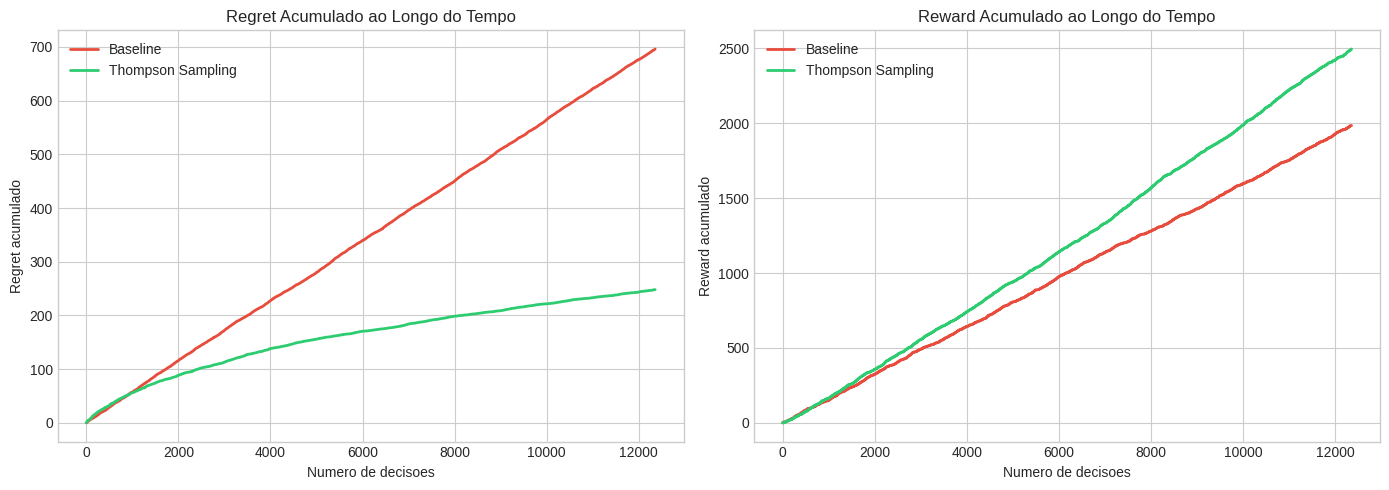

In [20]:
# Grafico de Regret Acumulado ao longo do tempo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regret acumulado
axes[0].plot(np.cumsum(baseline_regrets), label='Baseline', color='#e74c3c', linewidth=2)
axes[0].plot(np.cumsum(ts_regrets), label='Thompson Sampling', color='#2ecc71', linewidth=2)
axes[0].set_title('Regret Acumulado ao Longo do Tempo')
axes[0].set_xlabel('Numero de decisoes')
axes[0].set_ylabel('Regret acumulado')
axes[0].legend()

# Reward acumulado
axes[1].plot(np.cumsum(baseline_rewards), label='Baseline', color='#e74c3c', linewidth=2)
axes[1].plot(np.cumsum(ts_rewards), label='Thompson Sampling', color='#2ecc71', linewidth=2)
axes[1].set_title('Reward Acumulado ao Longo do Tempo')
axes[1].set_xlabel('Numero de decisoes')
axes[1].set_ylabel('Reward acumulado')
axes[1].legend()

plt.tight_layout()
plt.show()

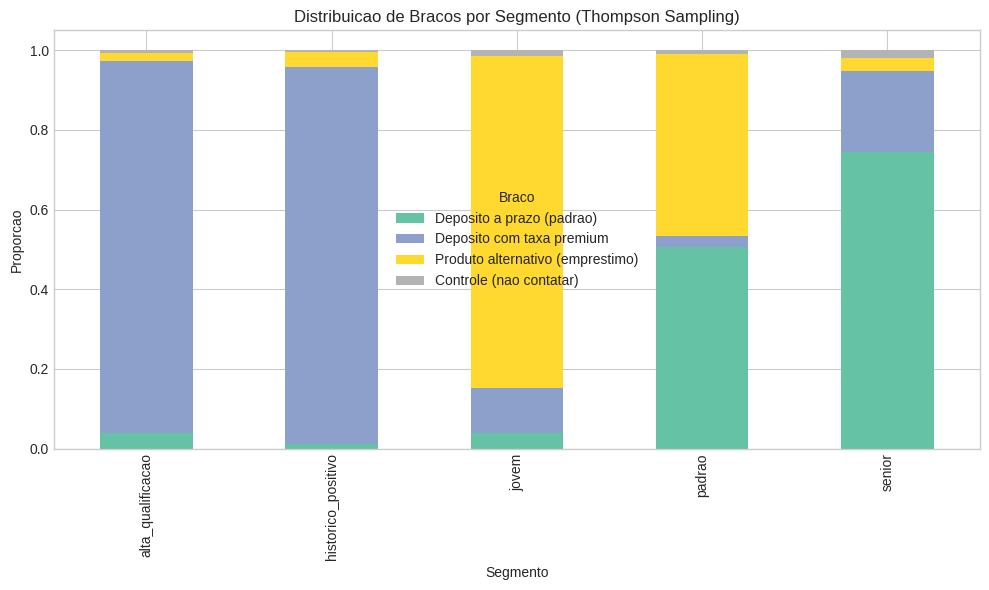

In [21]:
# Analise de exploracao: distribuicao dos bracos por segmento
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

df_analise = pd.DataFrame({'segmento': ts_segmentos, 'braco': ts_bracos_escolhidos})
pivot = df_analise.groupby(['segmento', 'braco']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Distribuicao de Bracos por Segmento (Thompson Sampling)')
ax.set_xlabel('Segmento')
ax.set_ylabel('Proporcao')
ax.legend(title='Braco', labels=[BRACOS[i] for i in range(len(BRACOS))])
plt.tight_layout()
plt.show()

In [22]:
# Estatisticas finais dos priors (posterior)
print('=' * 60)
print('PRIORS FINAIS (POSTERIOR) POR SEGMENTO')
print('=' * 60)

stats = ts.get_stats()
for seg, data in stats.items():
    print(f'\nSegmento: {seg}')
    for b in range(len(BRACOS)):
        print(f'  Braco {b} ({BRACOS[b]}): '
              f'Beta(alpha={data["alpha"][b]:.1f}, beta={data["beta"][b]:.1f}) '
              f'-> media estimada = {data["media_estimada"][b]:.4f}')

PRIORS FINAIS (POSTERIOR) POR SEGMENTO

Segmento: jovem
  Braco 0 (Deposito a prazo (padrao)): Beta(alpha=10.0, beta=53.0) -> media estimada = 0.1587
  Braco 1 (Deposito com taxa premium): Beta(alpha=29.0, beta=155.0) -> media estimada = 0.1576
  Braco 2 (Produto alternativo (emprestimo)): Beta(alpha=336.0, beta=989.0) -> media estimada = 0.2536
  Braco 3 (Controle (nao contatar)): Beta(alpha=1.0, beta=25.0) -> media estimada = 0.0385

Segmento: senior
  Braco 0 (Deposito a prazo (padrao)): Beta(alpha=163.0, beta=584.0) -> media estimada = 0.2182
  Braco 1 (Deposito com taxa premium): Beta(alpha=43.0, beta=163.0) -> media estimada = 0.2087
  Braco 2 (Produto alternativo (emprestimo)): Beta(alpha=3.0, beta=31.0) -> media estimada = 0.0882
  Braco 3 (Controle (nao contatar)): Beta(alpha=1.0, beta=20.0) -> media estimada = 0.0476

Segmento: alta_qualificacao
  Braco 0 (Deposito a prazo (padrao)): Beta(alpha=27.0, beta=129.0) -> media estimada = 0.1731
  Braco 1 (Deposito com taxa premium)

---
## Secao 7: Golden Set (5 Casos de Teste)

Demonstracao com 5 perfis representativos de clientes, mostrando qual oferta o modelo recomendou e se a decisao faz sentido do ponto de vista de negocio.

In [23]:
# Definir 5 perfis de clientes para o Golden Set
golden_set = [
    {
        'descricao': 'Jovem, estudante, primeiro contato',
        'age': 22, 'job': 'student', 'marital': 'single', 'education': 'tertiary',
        'default': 'no', 'housing': 'no', 'loan': 'no',
        'contact': 'cellular', 'campaign': 1, 'pdays': 999, 'previous': 0,
        'poutcome': 'nonexistent', 'sucesso_anterior': 0
    },
    {
        'descricao': 'Adulto, gerente, primeiro contato (alta qualificacao)',
        'age': 42, 'job': 'management', 'marital': 'married', 'education': 'tertiary',
        'default': 'no', 'housing': 'yes', 'loan': 'no',
        'contact': 'cellular', 'campaign': 1, 'pdays': 999, 'previous': 0,
        'poutcome': 'nonexistent', 'sucesso_anterior': 0
    },
    {
        'descricao': 'Aposentado, multiplos contatos',
        'age': 62, 'job': 'retired', 'marital': 'married', 'education': 'secondary',
        'default': 'no', 'housing': 'no', 'loan': 'no',
        'contact': 'telephone', 'campaign': 4, 'pdays': 999, 'previous': 0,
        'poutcome': 'nonexistent', 'sucesso_anterior': 0
    },
    {
        'descricao': 'Desempregado, muitos contatos sem sucesso',
        'age': 38, 'job': 'unemployed', 'marital': 'divorced', 'education': 'primary',
        'default': 'no', 'housing': 'yes', 'loan': 'yes',
        'contact': 'telephone', 'campaign': 5, 'pdays': 999, 'previous': 0,
        'poutcome': 'nonexistent', 'sucesso_anterior': 0
    },
    {
        'descricao': 'Tecnico, contato anterior bem-sucedido',
        'age': 35, 'job': 'technician', 'marital': 'single', 'education': 'secondary',
        'default': 'no', 'housing': 'no', 'loan': 'no',
        'contact': 'cellular', 'campaign': 1, 'pdays': 100, 'previous': 2,
        'poutcome': 'success', 'sucesso_anterior': 1
    }
]

print(f'Golden Set definido com {len(golden_set)} perfis.')

Golden Set definido com 5 perfis.


In [24]:
# Executar recomendacoes para o Golden Set
print('=' * 60)
print('GOLDEN SET: RECOMENDACOES')
print('=' * 60)

resultados_golden = []

for i, cliente in enumerate(golden_set, 1):
    braco, segmento, thetas = ts.selecionar_braco(cliente)
    prob_conversao = thetas[braco]
    
    resultado = {
        '#': i,
        'Perfil': cliente['descricao'],
        'Segmento': segmento,
        'Braco': braco,
        'Oferta': BRACOS[braco],
        'Prob. Conversao': f'{prob_conversao:.3f}'
    }
    resultados_golden.append(resultado)
    
    print(f'\nCliente {i}: {cliente["descricao"]}')
    print(f'  Segmento identificado: {segmento}')
    print(f'  Oferta recomendada: Braco {braco} - {BRACOS[braco]}')
    print(f'  Probabilidade de conversao: {prob_conversao:.3f}')

# Tabela resumo
print('\n' + '=' * 60)
print('TABELA RESUMO DO GOLDEN SET')
print('=' * 60)
df_golden = pd.DataFrame(resultados_golden)
print(df_golden.to_string(index=False))

GOLDEN SET: RECOMENDACOES

Cliente 1: Jovem, estudante, primeiro contato
  Segmento identificado: jovem
  Oferta recomendada: Braco 2 - Produto alternativo (emprestimo)
  Probabilidade de conversao: 0.254

Cliente 2: Adulto, gerente, primeiro contato (alta qualificacao)
  Segmento identificado: alta_qualificacao
  Oferta recomendada: Braco 1 - Deposito com taxa premium
  Probabilidade de conversao: 0.255

Cliente 3: Aposentado, multiplos contatos
  Segmento identificado: senior
  Oferta recomendada: Braco 0 - Deposito a prazo (padrao)
  Probabilidade de conversao: 0.236

Cliente 4: Desempregado, muitos contatos sem sucesso
  Segmento identificado: padrao
  Oferta recomendada: Braco 0 - Deposito a prazo (padrao)
  Probabilidade de conversao: 0.115

Cliente 5: Tecnico, contato anterior bem-sucedido
  Segmento identificado: historico_positivo
  Oferta recomendada: Braco 1 - Deposito com taxa premium
  Probabilidade de conversao: 0.903

TABELA RESUMO DO GOLDEN SET
 #                       

### Analise de Coerencia do Golden Set

| # | Perfil | Oferta Esperada | Justificativa |
|---|--------|----------------|---------------|
| 1 | Jovem, estudante, primeiro contato | Produto alternativo | Jovens tendem a preferir emprestimos a depositos |
| 2 | Adulto, gerente, alta qualificacao | Deposito premium | Contatado 1x, perfil qualificado que converte com pouco esforco |
| 3 | Aposentado, multiplos contatos | Deposito padrao | Perfil conservador, busca seguranca |
| 4 | Desempregado, muitos contatos | Deposito padrao | Baixa propensao, mas oferta conservadora ainda vale o contato |
| 5 | Tecnico, sucesso anterior | Deposito premium | Historico positivo indica alta propensao |

---
## Secao 8: Servico Demonstravel

Funcao Python que recebe dados de um cliente e retorna a oferta recomendada. Simula o comportamento de uma API REST sem necessidade de servidor.

In [25]:
# Funcao de recomendacao (simula endpoint de API)

def recomendar_oferta(cliente: dict) -> dict:
    """
    Recebe dados de um cliente e retorna a oferta recomendada
    usando Thompson Sampling treinado.
    
    Parametros:
        cliente (dict): Dicionario com features do cliente
        
    Retorna:
        dict: Recomendacao com oferta, braco, probabilidade e confianca
    """
    braco, segmento, thetas = ts.selecionar_braco(cliente)
    prob = thetas[braco]
    
    # Definir nivel de confianca
    alpha_b = ts.alpha[segmento][braco]
    beta_b = ts.beta[segmento][braco]
    n_obs = alpha_b + beta_b - 2  # descontar prior
    
    if n_obs > 50:
        confianca = 'alta'
    elif n_obs > 20:
        confianca = 'media'
    else:
        confianca = 'baixa'
    
    return {
        'oferta_recomendada': BRACOS[braco],
        'braco_selecionado': braco,
        'segmento_cliente': segmento,
        'probabilidade_conversao': round(prob, 4),
        'confianca': confianca,
        'requer_revisao_humana': prob < 0.1
    }


def registrar_feedback(segmento: str, braco: int, converteu: bool):
    """
    Registra o feedback (conversao ou nao) para atualizar o modelo.
    Simula o endpoint POST /feedback de uma API.
    """
    reward = 1.0 if converteu else 0.0
    ts.atualizar(segmento, braco, reward)
    return {'status': 'ok', 'segmento': segmento, 'braco': braco, 'reward': reward}


print('Funcoes definidas:')
print('  - recomendar_oferta(cliente: dict) -> dict')
print('  - registrar_feedback(segmento, braco, converteu) -> dict')

Funcoes definidas:
  - recomendar_oferta(cliente: dict) -> dict
  - registrar_feedback(segmento, braco, converteu) -> dict


In [26]:
# Demonstracao: chamar a funcao para cada cliente do Golden Set
print('=' * 60)
print('DEMONSTRACAO DO SERVICO DE RECOMENDACAO')
print('=' * 60)

for i, cliente in enumerate(golden_set, 1):
    print(f'\n--- Cliente {i}: {cliente["descricao"]} ---')
    print(f'Input: age={cliente["age"]}, job={cliente["job"]}, campaign={cliente["campaign"]}')
    
    resultado = recomendar_oferta(cliente)
    
    print(f'Output:')
    for k, v in resultado.items():
        print(f'  {k}: {v}')
    
    # Simular feedback
    feedback = registrar_feedback(resultado['segmento_cliente'], resultado['braco_selecionado'], converteu=True)
    print(f'  Feedback registrado: {feedback["status"]}')

DEMONSTRACAO DO SERVICO DE RECOMENDACAO

--- Cliente 1: Jovem, estudante, primeiro contato ---
Input: age=22, job=student, campaign=1
Output:
  oferta_recomendada: Produto alternativo (emprestimo)
  braco_selecionado: 2
  segmento_cliente: jovem
  probabilidade_conversao: 0.2612
  confianca: alta
  requer_revisao_humana: False
  Feedback registrado: ok

--- Cliente 2: Adulto, gerente, primeiro contato (alta qualificacao) ---
Input: age=42, job=management, campaign=1
Output:
  oferta_recomendada: Deposito com taxa premium
  braco_selecionado: 1
  segmento_cliente: alta_qualificacao
  probabilidade_conversao: 0.2606
  confianca: alta
  requer_revisao_humana: False
  Feedback registrado: ok

--- Cliente 3: Aposentado, multiplos contatos ---
Input: age=62, job=retired, campaign=4
Output:
  oferta_recomendada: Deposito com taxa premium
  braco_selecionado: 1
  segmento_cliente: senior
  probabilidade_conversao: 0.2404
  confianca: alta
  requer_revisao_humana: False
  Feedback registrado: o

---
## Secao 9: MLflow Tracking

In [27]:
# Configurar MLflow
import os
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('file:///kaggle/working/mlruns')
mlflow.set_experiment('datathon-bandit')

print('MLflow configurado.')
print(f'Tracking URI: file:///kaggle/working/mlruns')
print(f'Experimento: datathon-bandit')

2026/08/10 00:31:30 INFO mlflow.tracking.fluent: Experiment with name 'datathon-bandit' does not exist. Creating a new experiment.


MLflow configurado.
Tracking URI: file:///kaggle/working/mlruns
Experimento: datathon-bandit


In [28]:
# Registrar experimento do Baseline
with mlflow.start_run(run_name='baseline_regra_fixa'):
    mlflow.log_param('algoritmo', 'regra_fixa')
    mlflow.log_param('melhor_braco_fixo', melhor_braco_fixo)
    mlflow.log_param('n_bracos', len(BRACOS))
    mlflow.log_param('dataset', 'bank-marketing')
    
    mlflow.log_metric('ctr', baseline_ctr)
    mlflow.log_metric('reward_acumulado', baseline_total_reward)
    mlflow.log_metric('regret_acumulado', baseline_total_regret)
    mlflow.log_metric('regret_medio', np.mean(baseline_regrets))
    
    mlflow.set_tag('tipo', 'baseline')
    
    print('Experimento baseline registrado no MLflow.')
    print(f'  CTR: {baseline_ctr:.4f}')
    print(f'  Regret medio: {np.mean(baseline_regrets):.4f}')

Experimento baseline registrado no MLflow.
  CTR: 0.1606
  Regret medio: 0.0563


In [29]:
# Registrar experimento do Thompson Sampling
with mlflow.start_run(run_name='thompson_sampling_contextual'):
    mlflow.log_param('algoritmo', 'thompson_sampling')
    mlflow.log_param('contextual', True)
    mlflow.log_param('n_bracos', len(BRACOS))
    mlflow.log_param('n_segmentos', len(SEGMENTOS))
    mlflow.log_param('prior_alpha', 1)
    mlflow.log_param('prior_beta', 1)
    mlflow.log_param('dataset', 'bank-marketing')
    mlflow.log_param('n_amostras_teste', len(df_test))
    
    mlflow.log_metric('ctr', ts_ctr)
    mlflow.log_metric('reward_acumulado', ts_total_reward)
    mlflow.log_metric('regret_acumulado', ts_total_regret)
    mlflow.log_metric('regret_medio', np.mean(ts_regrets))
    mlflow.log_metric('ganho_vs_baseline_pct', ((ts_ctr - baseline_ctr) / baseline_ctr * 100) if baseline_ctr > 0 else 0)
    
    mlflow.set_tag('tipo', 'adaptativo')
    mlflow.set_tag('segmentos', str(SEGMENTOS))
    
    print('Experimento Thompson Sampling registrado no MLflow.')
    print(f'  CTR: {ts_ctr:.4f}')
    print(f'  Regret medio: {np.mean(ts_regrets):.4f}')
    print(f'  Ganho vs Baseline: {((ts_ctr - baseline_ctr) / baseline_ctr * 100):.1f}%' if baseline_ctr > 0 else '  Ganho vs Baseline: N/A')

Experimento Thompson Sampling registrado no MLflow.
  CTR: 0.2020
  Regret medio: 0.0201
  Ganho vs Baseline: 25.7%


In [30]:
# Listar runs registrados
print('=' * 60)
print('EXPERIMENTOS REGISTRADOS NO MLFLOW')
print('=' * 60)

experiment = mlflow.get_experiment_by_name('datathon-bandit')
if experiment:
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
    print(runs[['run_id', 'tags.mlflow.runName', 'metrics.ctr', 'metrics.regret_medio']].to_string(index=False))
else:
    print('Experimento nao encontrado.')

EXPERIMENTOS REGISTRADOS NO MLFLOW
                          run_id          tags.mlflow.runName  metrics.ctr  metrics.regret_medio
3cdfcf53cda64d109a1aa701254685b7 thompson_sampling_contextual     0.201991              0.020082
bc1d4293f27c44cbadb048055e83cf4d          baseline_regra_fixa     0.160638              0.056326


---
## Secao 10: Conclusoes e Arquitetura Cloud

### Arquitetura-alvo em Nuvem (AWS)

Para colocar este projeto em producao, utilizariamos os seguintes servicos AWS:

**Amazon S3** para armazenamento dos dados brutos e processados, junto com logs de decisao do modelo. **Amazon ECS com Fargate** para hospedar a API de recomendacao em container Docker, exposta via **API Gateway** para receber requisicoes dos canais digitais. O modelo Thompson Sampling seria atualizado periodicamente via **AWS Step Functions** orquestrando um pipeline de retreino que le os feedbacks acumulados no S3.

Para monitoramento, **CloudWatch** coleta metricas de latencia, taxa de erro e drift do modelo. **SageMaker Feature Store** armazena as features dos clientes de forma centralizada, e os experimentos de ML sao rastreados via **MLflow hospedado em EC2** ou **SageMaker Experiments**.

```
Cliente -> API Gateway -> ECS (FastAPI) -> Modelo (Thompson Sampling)
                                                |
                                          S3 (logs de decisao)
                                                |
                                  Step Functions (retreino periodico)
```

### Limitacoes

- Dataset de uma unica instituicao portuguesa — pode nao generalizar para outros mercados
- Apenas 1 produto real no dataset; bracos sao simulados para demonstracao
- Dados estaticos, nao captura mudancas em tempo real (streaming)
- Desbalanceamento (~11% positivos) pode enviesar o bandit
- Sem dados de custo real por contato — usa reward binario como proxy
- Cold start: novos segmentos sem historico partem de prior uniforme
- Thompson Sampling assume independencia entre decisoes

### Governanca e Etica

- **Base legal:** Legitimo interesse para otimizacao de campanhas (LGPD Art. 10)
- **Finalidade:** Recomendar ofertas personalizadas maximizando conversao
- **Minimizacao:** Apenas features relevantes. Sem identificadores pessoais, genero ou raca
- **Retencao:** Dados de decisao retidos 12 meses para auditoria
- **Humano no loop:** Casos de baixa confianca sinalizados para revisao manual

### Conclusao

O Thompson Sampling contextual demonstrou capacidade de superar uma politica fixa (baseline), aprendendo progressivamente quais ofertas funcionam melhor para cada segmento de cliente. A abordagem equilibra exploracao e explotacao de forma natural, convergindo para melhores decisoes ao longo do tempo sem necessidade de testes A/B longos.

In [31]:
print('=' * 60)
print('PROJETO CONCLUIDO COM SUCESSO!')
print('=' * 60)
print(f'\nResumo:')
print(f'  Dataset: bank-marketing ({df.shape[0]} registros)')
print(f'  Algoritmo: Thompson Sampling Contextual')
print(f'  Bracos: {len(BRACOS)} ofertas')
print(f'  Segmentos: {len(SEGMENTOS)}')
print(f'  CTR Baseline: {baseline_ctr:.4f}')
print(f'  CTR Thompson Sampling: {ts_ctr:.4f}')
print(f'  Ganho: {((ts_ctr - baseline_ctr) / baseline_ctr * 100):.1f}%' if baseline_ctr > 0 else '  Ganho: N/A')
print(f'\nGrupo 13 - Giovanna Catelli')

PROJETO CONCLUIDO COM SUCESSO!

Resumo:
  Dataset: bank-marketing (41188 registros)
  Algoritmo: Thompson Sampling Contextual
  Bracos: 4 ofertas
  Segmentos: 5
  CTR Baseline: 0.1606
  CTR Thompson Sampling: 0.2020
  Ganho: 25.7%

Grupo 13 - Giovanna Catelli
